# Initialize Git Repository
https://docs.ycrc.yale.edu/clusters-at-yale/guides/github/

In [1]:
#git init -b main  # Initializes the repo with 'main' as the default branch
#git add .
#git commit -m "Initial commit"
#git remote add origin git@github.com:innacohen/mod-extract.git
#git push -u origin main --force

# Download mod files as a single JSON file

In [2]:
#see downwload_mod_files.ipynb

# Read the Annotation Data

In [3]:
import pandas as pd
import numpy as np

In [4]:
#Converted to long format in R
df_raw = pd.read_csv("../data/annotations_long.csv")
keep = ["row_id", "file_hash","type","subtype_confidence","notes_free_text","label"]
df_anno = df_raw[keep].copy()

In [5]:
df_anno

,row_id,file_hash,type,subtype_confidence,notes_free_text,label
0,1,f8be35d0c20d1b1f3de4c44323e1780ee24f06893b6364...,I Na,3 - Highly confident,NaN,i_na_persistent
1,2,e97ca8a7f9734805832e5ae75442d19d3d7796b9a24190...,I K,2 - Mildly confident,STATES n l taul = 0.26*(v+50)/qtl,i_k_a_type_slow
2,4,606423f8f4a4f406f3387c7ee6f142bd121237272c347d...,Receptor,3 - Highly confident,NaN,r_gaba_type_a
3,5,99713c0032634e96cc7cde2dce02d8aa2baf75ad4cc835...,Receptor,3 - Highly confident,NaN,r_gaba_general
4,6,2d34ae241d628e7f25374c1bd84a8138cedc6a54689568...,Receptor,3 - Highly confident,mix,r_glutamate_ampa
...,...,...,...,...,...,...
414,462,ed87e94223dec25e43020f389207c0e362361efd05f3b0...,I Na,3 - Highly confident,NaN,i_na_transient
415,463,414840eea6fe6455d3377f99f43543155d2e4771b8cf8c...,I Ca,3 - Highly confident,NaN,i_ca_t_type_lt
416,464,43cdc726cbc3bc20eb08263de0028f8bfba35edba720eb...,Exclude,3 - Highly confident,NaN,exclude_accumulation_mechanism
417,467,abd4902abc5ad78269b6b9a4cc6d430bdd2bdd777cafd2...,I K,3 - Highly confident,NaN,i_k_delayed_rectifier


In [6]:
neither_subtypes = df_anno[df_anno["type"]=="Exclude"]

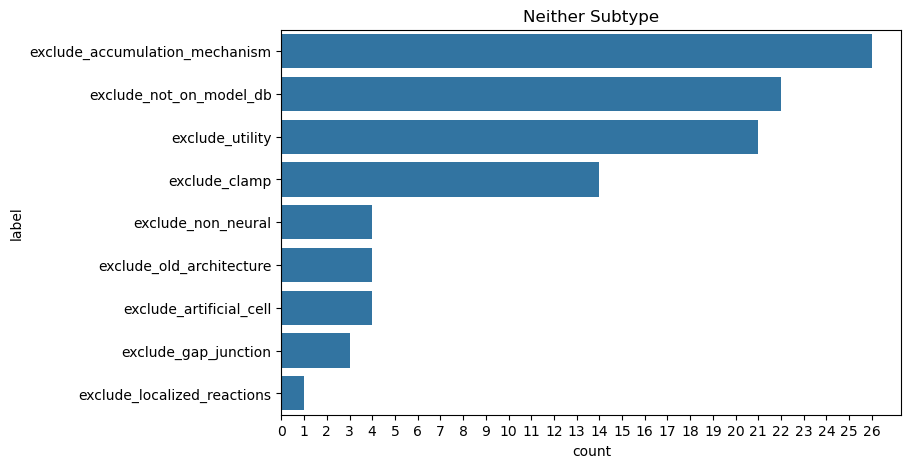

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Compute counts and sort labels by count in descending order
label_counts = neither_subtypes['label'].value_counts().sort_values(ascending=False)

# Create a count plot with different colors
plt.figure(figsize=(8, 5))
ax = sns.countplot(y='label', data=neither_subtypes, order=label_counts.index)

# Ensure only whole numbers appear on the x-axis
ax.set_xticks(np.arange(0, label_counts.max() + 1, 1))  # Set integer x-ticks

# Add a title
plt.title('Neither Subtype')

# Show the plot
plt.show()


In [8]:
neither_subtypes["label"].value_counts()

label
exclude_accumulation_mechanism    26
exclude_not_on_model_db           22
exclude_utility                   21
exclude_clamp                     14
exclude_non_neural                 4
exclude_old_architecture           4
exclude_artificial_cell            4
exclude_gap_junction               3
exclude_localized_reactions        1
Name: count, dtype: int64

# Feature Engineering

In [9]:
import os
import pandas as pd
import requests
import json
import re
from bs4 import BeautifulSoup
from tqdm import tqdm
from sklearn.preprocessing import MultiLabelBinarizer
pd.set_option("display.max_columns", None)

In [10]:
def View(df, rows=None, cols=None, width=None):
    """Displays the first `rows` of the DataFrame like R's View() by adjusting Pandas settings."""
    
    # Show only the first `rows` of the DataFrame
    with pd.option_context(
        "display.max_rows", rows,  # Limit number of rows shown
        "display.max_columns", cols,  # Show all columns
        "display.max_colwidth", width,  # Show full column width
        "display.expand_frame_repr", False  # Prevent column wrapping
    ):
        display(df.head(rows))  # Show only the first `rows`


In [11]:
# Function to extract mod directory from the URL
def get_dir(url):
    match = re.search(r"file=([^/]+)/[^/]+\.mod", url)  # Extract the directory name before the .mod file
    return match.group(1) if match else None  # Return directory name if found, else None

# Function to extract mod file name without extension
def get_fname(url):
    match = re.search(r"/([^/]+)\.mod$", url)  # Get filename without extension
    return match.group(1) if match else None  # Return only the name (e.g., 'na')

# Function to extract model_id from the URL
def get_model_id(url):
    match = re.search(r"https://modeldb\.science/(\d+)", url)
    return int(match.group(1)) if match else None  # Convert to integer

# Function to extract all TITLE occurrences from .mod content
def get_title(content):
    if pd.isna(content):  
        return None
    matches = re.findall(r"^TITLE\s+([^\n:]+)", content, re.MULTILINE)  # Stop at comments
    return matches if matches else None

# Function to extract all COMMENT sections from .mod content
def get_comment(content):
    if pd.isna(content):  
        return None
    matches = re.findall(r"COMMENT\s+(.*?)(?:\s+ENDCOMMENT|\Z)", content, re.DOTALL)  
    return matches if matches else None

# Function to extract all SUFFIX occurrences from .mod content
def get_suffix(content):
    if pd.isna(content):  
        return None
    matches = re.findall(r"SUFFIX\s+([^\n:\s]+)", content, re.MULTILINE)  # Stop at comments
    return matches if matches else None


def get_use_ion(content):
    """
    Extracts the ion names used in the 'USEION' statements from NEURON mod file content.

    Parameters:
    - content (str): The content of the .mod file.

    Returns:
    - list: A list of ions used in 'USEION' statements, or None if none are found.
    """
    if pd.isna(content):  
        return None
    
    # Find all occurrences of USEION followed by an ion name
    matches = re.findall(r"USEION\s+(\w+)", content, re.MULTILINE)

    return matches if matches else None


# Function to extract all ions listed after READ but stopping before WRITE, USEION, RANGE, GLOBAL, NONSPECIFIC_CURRENT, or VALENCE
def get_read_ion(content):
    if pd.isna(content):  
        return None
    
    matches = re.findall(r"USEION\s+\w+\s+READ\s+([\w,\s]+?)(?=\s+(?:WRITE|USEION|RANGE|GLOBAL|NONSPECIFIC_CURRENT|VALENCE|:|\n|$))", content, re.MULTILINE)

    if not matches:
        return None

    read_ions = [ion.strip() for match in matches for ion in re.split(r"[,\s]+", match) if ion]

    return read_ions if read_ions else None  


# Function to extract all ions listed after WRITE, stopping before VALENCE
def get_write_ion(content):
    if pd.isna(content):  
        return None

    matches = re.findall(r"WRITE\s+([^\n:]+?)(?=\s+(?:VALENCE|:|\n|$))", content, re.MULTILINE)

    if not matches:
        return None

    write_ions = [ion.strip() for match in matches for ion in re.split(r"[,\s]+", match) if ion]

    return write_ions if write_ions else None  


def write_current_yn(ions):
    """
    Checks if mod_write_ion contains an ion that starts with 'i' (indicating a current).

    Args:
        write_ions (list): List of ions written in the mod file.

    Returns:
        int: 1 if any ion starts with 'i', otherwise 0.
    """
    if not ions:  # Handle empty lists or None
        return 0

    return int(any(ion.startswith("i") for ion in ions))


# Function to extract all NONSPECIFIC currents
def get_nonspecific_current(content):
    if pd.isna(content):  
        return None

    matches = re.findall(r"NONSPECIFIC_CURRENT\s+([^\n:]*)", content)

    if not matches:
        return None

    nonspecific_currents = [curr.strip() for match in matches for curr in re.split(r"[,\s]+", match) if curr]

    return nonspecific_currents if nonspecific_currents else None  

#todo: should we assume we only want active variables or also extract ones that are commented out?
# Function to extract RANGE variables based on mode
def get_range(content, mode="active"):
    if pd.isna(content):
        return None  # Return None if content is missing

    # Extract active RANGE variables (not commented out)
    active_matches = re.findall(r"^\s*RANGE\s+([\w\s,]+)", content, re.MULTILINE)

    # Extract commented-out RANGE variables (lines starting with ": RANGE")
    commented_matches = re.findall(r"^\s*:\s*RANGE\s+([\w\s,]+)", content, re.MULTILINE)

    # Process active RANGE variables
    active_vars = [var.strip() for match in active_matches for var in re.split(r"[,\s]+", match) if var]

    # Process commented-out RANGE variables
    commented_vars = [var.strip() for match in commented_matches for var in re.split(r"[,\s]+", match) if var]

    if mode == "active":
        return active_vars if active_vars else None
    elif mode == "commented":
        return commented_vars if commented_vars else None
    elif mode == "all":
        return {"active": active_vars if active_vars else None, "commented": commented_vars if commented_vars else None}
    else:
        raise ValueError("Invalid mode! Choose from 'all', 'active', or 'commented'.")


# Function to extract only active RANGE variables, stopping at colons and the end of the line
def get_range(content):
    if pd.isna(content):
        return None  # Return None if content is missing

    # Extract all RANGE statements (each line separately), stopping before colons
    matches = re.findall(r"^\s*RANGE\s+([^\n:]*)", content, re.MULTILINE)

    if not matches:
        return None

    # Process active RANGE variables, ensuring they don't capture anything past the colon
    active_vars = [var.strip() for match in matches for var in re.split(r"[,\s]+", match) if var]

    return active_vars if active_vars else None  # Return only active variables
    
# Function to extract parameter names and values as a dictionary
def get_parameter(content):
    if pd.isna(content):  
        return None
    
    matches = re.findall(r"PARAMETER\s*\{([^}]*)\}", content, re.MULTILINE)

    if not matches:
        return None

    param_dict = {}
    
    for match in matches:
        for line in match.split("\n"):
            line = line.strip()
            if line.startswith(":"):  # Ignore commented-out lines
                continue
            param_match = re.match(r"(\w+)\s*=\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)", line)
            if param_match:
                param_name, param_value = param_match.groups()
                param_dict[param_name] = float(param_value)  

    return param_dict if param_dict else None  

# Function to extract only active STATE variables, ignoring comments (`:`) and unit values `(mV)`, etc.
def get_state(content):
    if pd.isna(content):  
        return None

    matches = re.findall(r"STATE\s*\{([^}]*)\}", content, re.MULTILINE)

    if not matches:
        return None

    state_vars = []
    for match in matches:
        for line in match.split("\n"):
            line = line.strip()
            if line.startswith(":"):  # Ignore fully commented-out lines
                continue
            line = re.split(r"\s*:\s*", line)[0]  # Remove inline comments (anything after `:`)
            clean_line = re.sub(r"\([^)]*\)", "", line).strip()  # Remove unit values
            if clean_line:
                state_vars.append(clean_line)

    return state_vars if state_vars else None  


# Function to extract only active GLOBAL variables, ignoring commented-out (`:`) ones
def get_global(content):
    if pd.isna(content):  
        return None

    matches = re.findall(r"^\s*GLOBAL\s+([^\n:]*)", content, re.MULTILINE)

    if not matches:
        return None

    global_vars = [var.strip() for match in matches for var in re.split(r"[,\s]+", match) if var]

    return global_vars if global_vars else None  


def get_net_receive(content):
    """
    Extracts all NET_RECEIVE block arguments from MOD file content.

    Args:
        content (str): The text content of the MOD file.

    Returns:
        list or None: A list of extracted NET_RECEIVE arguments, or None if not found.
    """
    if pd.isna(content):  # Handle missing content
        return None

    # Find all occurrences of NET_RECEIVE and extract arguments
    matches = re.findall(r"^\s*NET_RECEIVE\s*\(\s*([\w, ]+)\s*\)", content, re.MULTILINE)

    if not matches:
        return None

    net_receive_vars = [var.strip() for match in matches for var in re.split(r"[,\s]+", match) if var]

    return net_receive_vars if net_receive_vars else None

#todo: modify pipeline so that if get_include points to a file that file will be included in the content too
def get_include(content):
    """
    Extracts the filename in the INCLUDE statement from MOD file content, ignoring comments.

    Args:
        content (str): The text content of the MOD file.

    Returns:
        list or None: A list of extracted INCLUDE filenames, or None if not found.
    """
    if pd.isna(content):  # Handle missing content
        return None

    # Find all occurrences of INCLUDE, ensuring commented-out ones (with ':') are ignored
    matches = re.findall(r"^\s*INCLUDE\s+\"([^\"]+)\"", content, re.MULTILINE)

    return matches if matches else None


def get_point_process(content):
    """
    Extracts the POINT_PROCESS name from MOD file content.

    Args:
        content (str): The text content of the MOD file.

    Returns:
        str or None: The extracted POINT_PROCESS name, or None if not found.
    """
    if pd.isna(content):  # Handle missing content
        return None

    # Extract the POINT_PROCESS name, ignoring comments
    match = re.search(r"^\s*POINT_PROCESS\s+([^\n:]+)", content, re.MULTILINE)

    return match.group(1).strip() if match else None


    
# Function to extract webpage heading
def get_heading(url):
    try:
        response = requests.get(url, timeout=10)  # Fetch the webpage
        response.raise_for_status()
        soup = BeautifulSoup(response.text, "html.parser")
        
        # Try extracting heading from the most relevant tag
        heading = soup.find("h1")  # Look for <h1> (main title)
        return heading.text.strip() if heading else None  # Return text or None
    except requests.exceptions.RequestException:
        return None  # Return None if the request fail

# Function to extract citation (text inside parentheses)
def get_citation(heading):
    if pd.isna(heading):
        return None
    match = re.search(r"\(([^)]+)\)", heading)  # Find text inside parentheses
    return match.group(1) if match else None  # Extract citation


# Function to extract first author(s) (removes "et al." and "al" correctly)
def get_author(citation):
    if pd.isna(citation):
        return None

    # Extract first author(s) before "et al" or variants
    match = re.search(r"^([\w\s&\-,]+?)(?:\s+et\s+al\.?|et)?(?:,|\s|$)", citation)  
    first_author = match.group(1).strip() if match else None  

    # Remove any trailing "al" left behind
    if first_author:
        first_author = re.sub(r"\b(al)\b", "", first_author, flags=re.IGNORECASE).strip()

    return first_author

# Function to extract the first year from citation (including shortened years like '20)
def get_year(citation):
    if pd.isna(citation):
        return None
    match = re.search(r"\b(19|20)?\d{2}\b|'\d{2}", citation)  # Find 4-digit or short year ('20)
    if match:
        return match.group(0).replace("'", "")  # Remove apostrophe but keep year as '20' if short
    return None  # Return None if no year found




def has_x86(url):
    """
    Checks if the given URL contains 'x86_64'.

    Parameters:
    - url (str): The URL to check.

    Returns:
    - int: 1 if 'x86_64' is present in the URL, 0 otherwise.
    """
    if pd.isna(url):  
        return None  # Return None for missing URLs
    return 1 if "x86_64" in url else 0


def has_error(error_code):
    """
    Checks if the given error code is not NaN (i.e., an error is present).

    Parameters:
    - error_code: The error code to check.

    Returns:
    - int: 1 if an error code is present (not NaN), 0 otherwise.
    """
    return 1 if error_code is not None else 0

def has_electrode_or_clamp(mod_name, content):
    """
    Checks whether 'clamp' is present in the mod file name OR 
    'ELECTRODE_CURRENT' is present in the NEURON mod file content.

    Parameters:
    - mod_name (str): The name of the .mod file.
    - content (str): The content of the .mod file.

    Returns:
    - int: 1 if either 'clamp' is in the mod name OR 'ELECTRODE_CURRENT' is in the content, 0 otherwise.
    """
    if pd.isna(mod_name) and pd.isna(content):
        return None  # Return None if both are missing

    has_clamp = bool(re.search(r"clamp", str(mod_name), re.IGNORECASE)) if pd.notna(mod_name) else False
    has_electrode = bool(re.search(r"\bELECTRODE_CURRENT\b", str(content))) if pd.notna(content) else False

    return 1 if has_clamp or has_electrode else 0

def map_ion(value):
    value = value.lower()  # Normalize to lowercase

    # Define regex-based categorization rules
    patterns = [
        (r'ca.*i$', 'ca_i'),
        (r'ca.*o$', 'ca_o'),
        (r'cl.*i$', 'cl_i'),
        (r'cl.*o$', 'cl_o'),
        (r'k.*i$', 'k_i'),
        (r'k.*o$', 'k_o'),
        (r'na.*i$', 'na_i'),
        (r'na.*o$', 'na_o'),
        (r'hco3.*i$', 'other_i'),
        (r'hco3.*o$', 'other_o'),
        (r'mgi$', 'mg_i'),  
        (r'mgo$', 'mg_o'),  
        (r'^img$', 'i_mg'),  
        (r'^emg$', 'e_mg'),
        (r'^e.*ca', 'e_ca'),
        (r'^e.*k', 'e_k'),
        (r'^e.*na', 'e_na'),
        (r'^e.*mg', 'e_mg'),
        (r'^e.*', 'e_other'),
        (r'^i.*ca', 'i_cal'),
        (r'^i.*k', 'i_k'),
        (r'^i.*cl', 'i_cl'),
        (r'^i.*na$', 'i_na'),  # FIX: Ensure "ina" is classified as "i_na"
        (r'^i.*mg', 'i_mg'),
        (r'^i.*', 'i_other'),
        (r'.*i$', 'other_i'),  # General rule: Anything ending in "i" is "other_i"
        (r'.*o$', 'other_o')   # General rule: Anything ending in "o" is "other_o"
    ]
    # Apply the regex patterns
    for pattern, category in patterns:
        if re.search(pattern, value):
            return category

    return "unknown"  # Default category if no match is found

def count_states(df, column_name="state"):
    """Counts the number of states in each row of the specified column."""
    df["count_states"] = df[column_name].apply(lambda x: len(x) if isinstance(x, list) else 0)
    return df

def map_new_label(value):
    if value in ['i_k_delayed_rectifier','I_KD']:
        return 'i_k_delayed_rectifier'
    elif value in ['r_glutamate_ampa','AMPA']:
        return 'r_glutamate_ampa'
    elif value in ['i_na_transient','I Na,t','I_Na,t']:
        return 'i_na_transient'
    elif value in ['i_ca_l_type_ht','I L high threshold']:
        return 'i_ca_l_type_ht'
    elif value in ['r_glutamate_nmda','NMDA']:
        return 'r_glutamate_nmda'
    elif value == 'i_other_mixed':
        return 'i_other_mixed'
    elif value in ['i_ca_t_type_lt', 'I T low threshold']:
        return 'i_ca_t_type_lt'
    elif value in ['i_h_hyperpolarization_activated','I h']:
        return 'i_h_hyperpolarization_activated'
    elif value in ['i_na_persistent', 'I Na,p']:
        return 'i_na_persistent'
    elif value in ['i_k_m_type','I M']:
        return 'i_k_m_type'
    
    elif value in ['i_ca_ca_pump', 'i_ca_calcium_activiated_non_specific',
                   'i_ca_general', 'i_ca_p_q_type', 'i_ca_q_type', 'i_ca_r_type', 'Ca pump','I Calcium','I Ca,p','I Q', 'I R','I p,q']:
        return 'i_ca_other'
    elif value in ['i_k_a_type_transient', 'i_k_a_type_slow', 'I A', 'I A, slow']:
        return 'i_k_a'
    elif value in ['i_k_ca_activated_general_bk_ik_sk_and_i_ahp_currents', 'i_k_ca_activated_bk',
                   'i_k_ahp', 'i_k_ca_activated_sk',   'I K,Ca', 'IK Bkca', 'IK Skca', 'I_AHP']:
        return 'i_k_ca'
    elif value in ['i_k_c_type', 'i_k_general', 'i_k_ht', 'i_k_ir',
                   'i_k_lt', 'i_k_resistent_persistent', 'i_kx_photoreceptor', 'I Potassium','Kir', 'Kir, inactivating', 'I_KHT', 'I_KLT', 'I_Ks']:
        return 'i_k_other'
    elif value in ['i_na_slow_inactivation', 'i_na_general',  'I K','I Na, slow inactivation', ]:
        return 'i_na_other'
    elif value in ['i_na_leak', 'i_leak_general', 'i_cl_leak', 'i_k_leak','I Cl, leak','I K,leak','I Na, leak','I Sodium','Na/Ca exchanger', 'Na/K pump',]:
        return 'i_leak'
    elif value in ['i_other_channelrhodopsin', 'i_other_cng', 'i_other_kcc2_transporter',
                   'i_other_modulator_activated', 'i_other_na_ca_exchanger',
                   'i_other_na_k_pump', 'i_nonspecific','Channelrhodopsin (ChR)','I Chloride', 'I C', 'I CAN','I_HCO3','KCC2','I N']:
        return 'i_other'
    elif value in ['r_gaba_type_a', 'r_gaba_general', 'r_gaba_type_b', 'Gaba', 'GabaA', 'GabaB']:
        return 'r_gaba'
    elif value in ['r_acetylcholine_general', 'r_amino_acid_glutamate','D1', 'D2', 'Dopaminergic Receptor','Kainate','P2X3']:
        return 'r_other'
    
    elif value in ['exclude_utility', 'exclude_non_neural', 'exclude_clamp',
                   'exclude_accumulation_mechanism', 'exclude_artificial_cell',
                   'exclude_gap_junction', 'exclude_localized_reactions']:
        return 'z_neither'
    
    return 'z_neither'


def map_broad_label(value):
    if value == "I K":
        return "i_k"
    elif value == "Exclude":
        return "neither"
    elif value == "Receptor":
        return "receptor"
    elif value == "I Na":
        return "i_na"
    elif value == "I Ca":
        return "i_ca"
    elif value in ["I Other/Mixed","I Cl","I H"]:
        return "i_other"
    else:
        return "check"  # Default label for unknown values

def get_tau(param_dict):
    if not isinstance(param_dict, dict):
        return None, None  # Return separate None values for direct unpacking

    # Extract values where the key contains 'tau'
    tau_values = [v for k, v in param_dict.items() if 'tau' in k.lower()]
    
    # If no tau values found, return (None, None)
    if not tau_values:
        return None, None
    
    # Compute min and max
    return min(tau_values), max(tau_values)


def get_e(param_dict):
    if not isinstance(param_dict, dict):
        return [None, None]  # Handle cases where the value is not a dictionary

    #todo: modify the v pattern so it takes like 2 characters max
    # Regex pattern to match variations of reversal potential names
    pattern = re.compile(r"^(e|rev|v|shift).*", re.IGNORECASE)

    # Extract values where the key matches the pattern
    e_values = [v for k, v in param_dict.items() if pattern.match(k)]

    # If no values found, return [None, None]
    if not e_values:
        return [None, None]

    # Compute min and max reversal potential
    return min(e_values), max(e_values)



def has_mg(content):
    """
    Checks if 'mg' appears anywhere in the given content.

    Args:
        content (str): The text content to search.

    Returns:
        int: 1 if 'mg' is found, 0 otherwise.
    """
    if pd.isna(content):  # Handle missing content
        return 0

    return int(bool(re.search(r"mg", content, re.IGNORECASE)))  # Convert Boolean to int


def has_ih(content):

    if pd.isna(content):  # Handle missing content
        return 0

    return int(bool(re.search(r"ih", content, re.IGNORECASE)))  # Convert Boolean to int

In [12]:
# Load JSON into DataFrame
df_all = pd.read_json("../data/mod_files.json")
#df_all.set_index("row_id", inplace=True)
# Add exclusion criteria as flags
df_all["exclude_error"] = df_all["error_code"].apply(has_error)
df_all["exclude_x86"] = df_all["url"].apply(has_x86)
df_anno2 = df_all.merge(df_anno, on=["row_id","file_hash"], how="inner")
df_anno2["new_label"] = df_anno2["label"].map(map_new_label)

In [13]:
#
#df_train2.loc[df_train2["exclude_x86"]==1].index == df_train2.loc[df_train2["label"]=="exclude_old_architecture"].index
#df_train2["file_hash"].nunique()
#df_train3 = df_train2.loc[(df_train2["exclude_error"] != 1) & (df_train2["exclude_x86"] != 1)] 
#df_train3["file_hash"].nunique()
#All the "exclude" labels need to be collapsed to "neither"
#df_train4["label"].value_counts()
#df_train3[df_train3["type"]=="Exclude"].index
#subtype_counts = pd.DataFrame(df_train4["label"].value_counts()).reset_index()
#list(subtype_counts[subtype_counts['count']>=10]['label'])
#subtype_counts[subtype_counts["count"] >= 10].sort_values(by="label").reset_index(drop=True)
#subtype_counts["new_label"] = subtype_counts["label"].map(map_new_label)
#subtype_counts["new_label"].unique()
#subtype_counts.groupby(["new_label","label"]).count()
#df['broad_label'] = df["type"].map(map_broad_label)


In [14]:
df = df_anno2.copy()

In [15]:
# Extract features from url
#df["heading"] = df["url"].apply(get_heading)  # Extract heading from webpage
#df["citation"] = df["heading"].apply(get_citation)
#df["first_author"] = df["citation"].apply(get_author)
#df["year"] = df["citation"].apply(get_year)  # Now handles multiple years

#df["dir"] = df["url"].apply(get_dir)
df["mod_name"] = df["url"].apply(get_fname)
#df["model_id"] = df["url"].apply(get_model_id)

#  Extract features from content
#df["title"] = df["content"].apply(get_title)
#df["comment"] = df["content"].apply(get_comment)
df["suffix"] = df["content"].apply(get_suffix)
#df["use_ion"] = df["content"].apply(get_use_ion)
df["read_ion"] = df["content"].apply(get_read_ion)
#Use empty list since cannot handle None
df['read_ion2'] = df['read_ion'].apply(lambda ion_list: list(set(map_ion(ion) for ion in ion_list)) if isinstance(ion_list, list) else [])
df["write_ion"] = df["content"].apply(get_write_ion)
df['write_ion2'] = df['write_ion'].apply(lambda ion_list: list(set(map_ion(ion) for ion in ion_list)) if isinstance(ion_list, list) else [])

#df["range"] = df["content"].apply(get_range)
#df["global"] = df["content"].apply(get_global)
df["parameter"] = df["content"].apply(get_parameter)
df["state"] = df["content"].apply(get_state)
df["net_receive"] = df["content"].apply(get_net_receive)
df["point_process"] = df["content"].apply(get_point_process)
df["nonspecific_current"] = df["content"].apply(get_nonspecific_current)

In [16]:
#Numeric Features
#df["tau_min"], df["tau_max"] = zip(*df["parameter"].apply(get_tau))
#df["e_min"], df["e_max"] = zip(*df["parameter"].apply(get_e))

#Discrete features
df["states_count"] = df["state"].apply(lambda x: len(x) if isinstance(x, list) else 0)

#Binary Features
df["clamp_yn"] = df.apply(lambda row: has_electrode_or_clamp(row["mod_name"], row["content"]), axis=1)
#suffix "none" will be treated as 0
df["suffix_yn"] = df["suffix"].apply(lambda x: 1 if isinstance(x, list) and len(x) > 0 
                                     else (0 if pd.isna(x) or x == "none" else 1))
df["point_process_yn"] = df["point_process"].apply(lambda x: 1 if pd.notna(x) else 0)
df["net_receive_yn"] = df["net_receive"].apply(lambda x: 1 if isinstance(x, list) and len(x) > 0 else (1 if pd.notna(x) else 0))
df["i_nonspecific_yn"] = df["nonspecific_current"].apply(lambda x: 1 if isinstance(x, list) and len(x) > 0 else (1 if pd.notna(x) else 0))
df["not_ion_channel_yn"] = ((df["suffix_yn"] == 0) & 
                          df["read_ion"].isna() & 
                          df["write_ion"].isna() & 
                          df["nonspecific_current"].isna()).astype(int)
df["not_receptor_yn"] = ((df["point_process_yn"] == 0) & 
                          (df["net_receive_yn"] == 0)).astype(int)

df["has_mg_yn"] = df["content"].apply(has_mg)
df["has_ih_yn"] = df["content"].apply(has_ih)


In [17]:
# Use MultiLabelBinarizer separately for read and write ions
mlb_read = MultiLabelBinarizer()
df_read_exploded = pd.DataFrame(mlb_read.fit_transform(df['read_ion2']), 
                                columns=[f'read_{col}_yn' for col in mlb_read.classes_])

mlb_write = MultiLabelBinarizer()
df_write_exploded = pd.DataFrame(mlb_write.fit_transform(df['write_ion2']), 
                                 columns=[f'write_{col}_yn' for col in mlb_write.classes_])

# Reset index before merging to avoid index mismatches
df = df.reset_index(drop=True)
df_read_exploded = df_read_exploded.reset_index(drop=True)
df_write_exploded = df_write_exploded.reset_index(drop=True)
df = df.drop(columns=['read_ion2', 'write_ion2']).join(df_read_exploded, rsuffix='_read_dup').join(df_write_exploded, rsuffix='_write_dup')

In [18]:
df_pre = df.set_index('file_hash').filter(regex=r'(_yn|_count|new_label)$')

In [19]:
df_pre.to_csv("preprocessed.csv")

# XGB model

In [20]:
import pandas as pd
import pickle
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [21]:
df_pre = pd.read_csv("preprocessed.csv", index_col='file_hash')

In [22]:
# Load and split data
X = df_pre.drop(columns=['new_label'])  # Features
y = df_pre['new_label']  # Target

# Stratified 80/20 train-test split to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# Merge train/test sets
df_train = X_train.copy()
df_train['new_label'] = y_train

df_test = X_test.copy()
df_test['new_label'] = y_test

# Save train and test datasets
df_train.to_csv("train.csv", index=False)
df_test.to_csv("test.csv", index=False)

In [23]:
# Encode categorical labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)  
y_test_encoded = label_encoder.transform(y_test)  

# Save the label encoder for later use
with open("label_encoder.pkl", "wb") as file:
    pickle.dump(label_encoder, file)

In [24]:
# Define XGBoost model
xgb_model = xgb.XGBClassifier(
    objective="multi:softmax",
    num_class=len(label_encoder.classes_),
    max_depth=6,
    learning_rate=0.1,
    n_estimators=100,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42
)

In [25]:
# Perform 5-Fold Cross-Validation on the Training Set
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_model, X_train, y_train_encoded, cv=kf, scoring='accuracy')

print(f"Cross-validation scores: {cv_scores}")
print(f"Mean Accuracy (CV): {cv_scores.mean():.4f}")

Cross-validation scores: [0.49253731 0.47761194 0.47761194 0.43283582 0.56716418]
Mean Accuracy (CV): 0.4896


In [26]:
# Train on Full Training Set
xgb_model.fit(X_train, y_train_encoded, verbose=True)

# Save the trained XGBoost model
with open("xgb_model.pkl", "wb") as file:
    pickle.dump(xgb_model, file)

In [27]:
from sklearn.metrics import classification_report, accuracy_score

# Predict on test data
y_test_pred_enc = xgb_model.predict(X_test)  # Get encoded predictions

# Convert predictions back to original labels
y_test_pred = label_encoder.inverse_transform(y_test_pred_enc)

# Accuracy on test data
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Generate classification report with meaningful labels
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_))


Test Accuracy: 0.4524

Classification Report on Test Set:
                                 precision    recall  f1-score   support

                 i_ca_l_type_ht       0.00      0.00      0.00         4
                     i_ca_other       0.00      0.00      0.00         3
                 i_ca_t_type_lt       0.00      0.00      0.00         3
i_h_hyperpolarization_activated       0.67      0.67      0.67         3
                          i_k_a       0.67      0.40      0.50         5
                         i_k_ca       0.83      1.00      0.91         5
          i_k_delayed_rectifier       0.38      0.60      0.46         5
                     i_k_m_type       0.00      0.00      0.00         2
                      i_k_other       0.00      0.00      0.00         2
                         i_leak       0.00      0.00      0.00         2
                     i_na_other       0.00      0.00      0.00         3
                i_na_persistent       0.00      0.00      0.00   

/home/imc33/.conda/envs/nn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/imc33/.conda/envs/nn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/imc33/.conda/envs/nn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [28]:
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# Predict on test data
y_test_pred_enc = xgb_model.predict(X_test)  # Get encoded predictions

# Convert predictions back to original labels
y_test_pred = label_encoder.inverse_transform(y_test_pred_enc)

# Accuracy on test data
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Generate classification report as a dictionary
report = classification_report(y_test, y_test_pred, target_names=label_encoder.classes_, output_dict=True)

# Convert to DataFrame
df_report = pd.DataFrame(report).transpose()

# Filter only worst-performing subtypes (F1-score == 0.00)
df_worst = df_report[df_report["f1-score"] == 0.00]

# Drop support column for better readability
df_worst = df_worst.drop(columns=["support"])

df_worst

Test Accuracy: 0.4524


/home/imc33/.conda/envs/nn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/imc33/.conda/envs/nn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/imc33/.conda/envs/nn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,precision,recall,f1-score
i_ca_l_type_ht,0.0,0.0,0.0
i_ca_other,0.0,0.0,0.0
i_ca_t_type_lt,0.0,0.0,0.0
i_k_m_type,0.0,0.0,0.0
i_k_other,0.0,0.0,0.0
i_leak,0.0,0.0,0.0
i_na_other,0.0,0.0,0.0
i_na_persistent,0.0,0.0,0.0
r_gaba,0.0,0.0,0.0
r_other,0.0,0.0,0.0


# Plots

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [30]:
df_train.shape

(335, 39)

In [31]:
df_test.shape

(84, 39)

In [32]:
subtypes = df_train[df_train["new_label"] != "z_neither"]

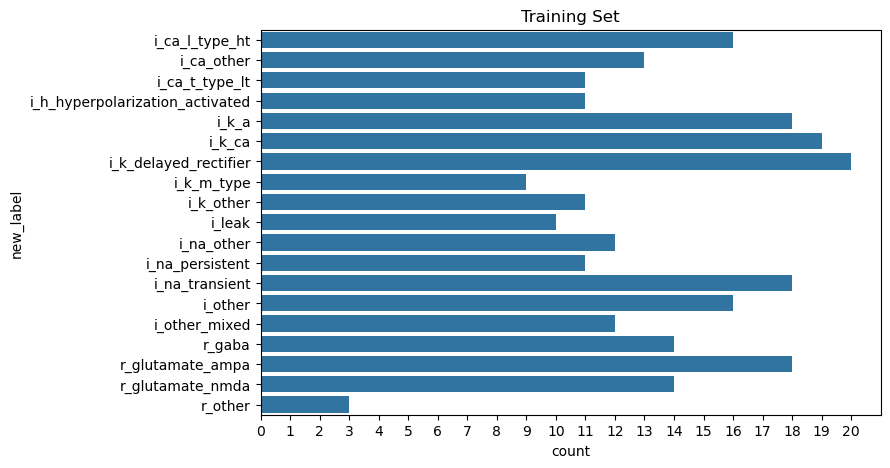

In [33]:
# Sort the DataFrame by 'new_label' in alphabetical order
subtypes = subtypes.sort_values(by='new_label')

# Create a count plot with different colors
plt.figure(figsize=(8, 5))
ax = sns.countplot(y='new_label', data=subtypes, order=subtypes['new_label'].unique())

# Ensure only whole numbers appear on the x-axis
max_count = subtypes['new_label'].value_counts().max()  # Get max count for setting x-ticks
ax.set_xticks(np.arange(0, max_count + 1, 1))  # Set integer x-ticks

# Add a title
plt.title('Training Set')

# Show the plot
plt.show()

In [34]:
subtypes = df_test[df_test["new_label"] != "z_neither"]

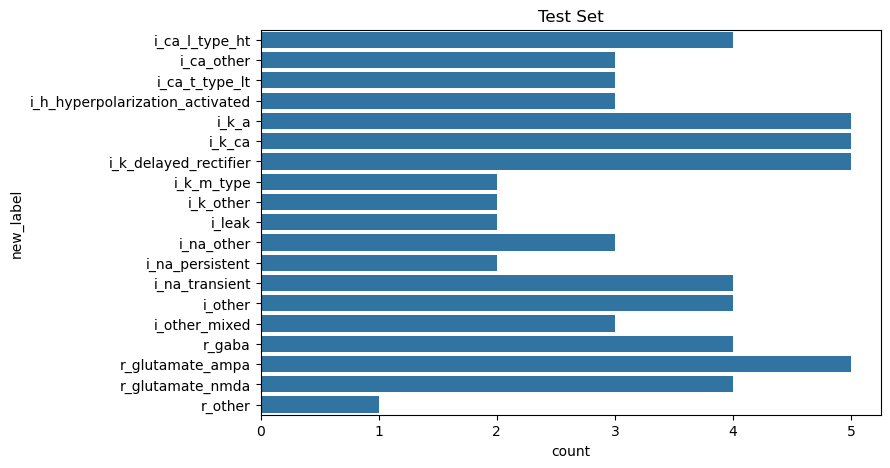

In [35]:
# Sort the DataFrame by 'new_label' in alphabetical order
subtypes = subtypes.sort_values(by='new_label')

# Create a count plot with different colors
plt.figure(figsize=(8, 5))
ax = sns.countplot(y='new_label', data=subtypes, order=subtypes['new_label'].unique())

# Ensure only whole numbers appear on the x-axis
max_count = subtypes['new_label'].value_counts().max()  # Get max count for setting x-ticks
ax.set_xticks(np.arange(0, max_count + 1, 1))  # Set integer x-ticks

# Add a title
plt.title('Test Set')

# Show the plot
plt.show()

<Figure size 1000x600 with 0 Axes>

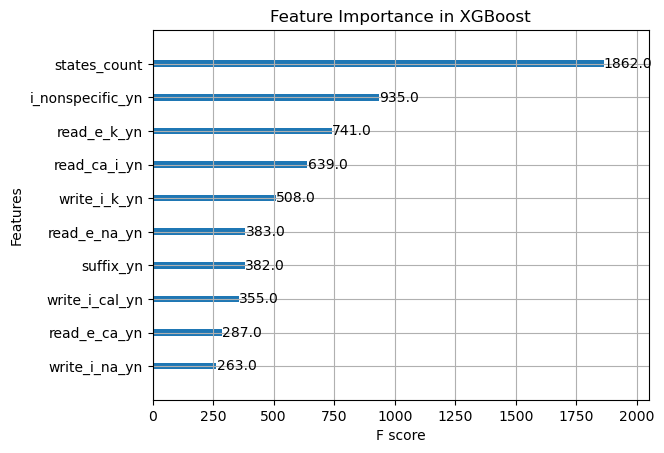

In [36]:
import matplotlib.pyplot as plt
import xgboost as xgb

# Plot feature importances
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, max_num_features=10)  # Show top 10 features
plt.title("Feature Importance in XGBoost")
plt.show()


In [37]:
import pandas as pd
from sklearn.metrics import confusion_matrix

# Ensure predictions are in encoded numeric form
y_test_pred_encoded = label_encoder.transform(y_test_pred)  # Convert back to numeric if necessary

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test_encoded, y_test_pred_encoded)

# Convert to DataFrame for better visualization
conf_df = pd.DataFrame(conf_matrix, 
                       index=label_encoder.classes_, 
                       columns=label_encoder.classes_)


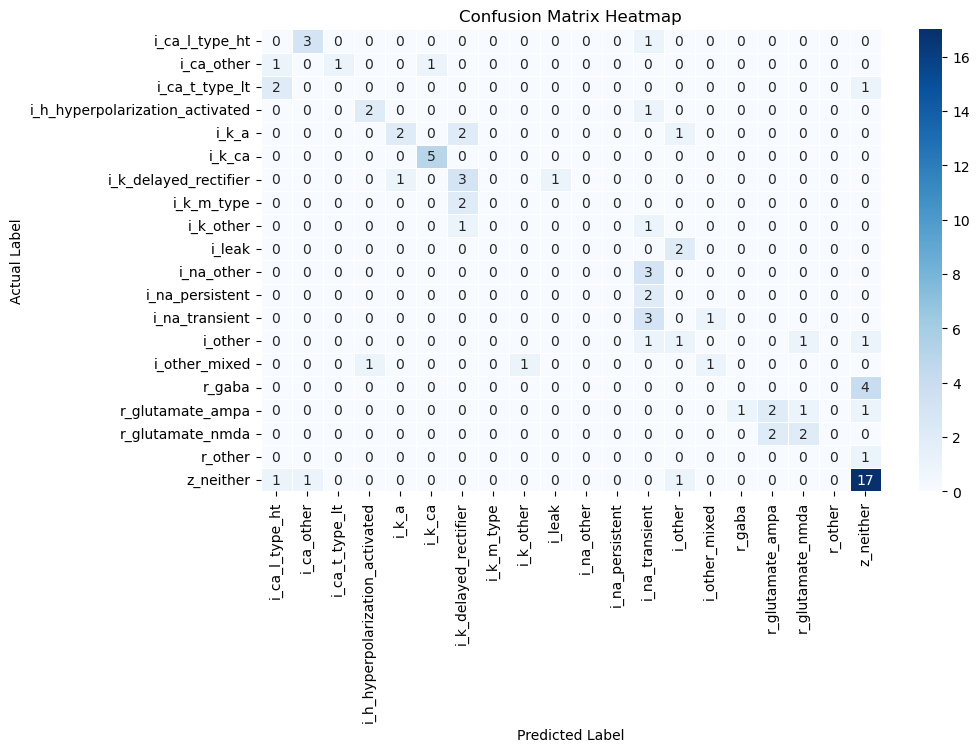

In [38]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(conf_df, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


In [39]:
import shap
import matplotlib.pyplot as plt

# Create an explainer
explainer = shap.Explainer(xgb_model, X_test)

# Compute SHAP values
shap_values = explainer(X_test)


 97%|=================== | 1630/1680 [00:27<00:00]       

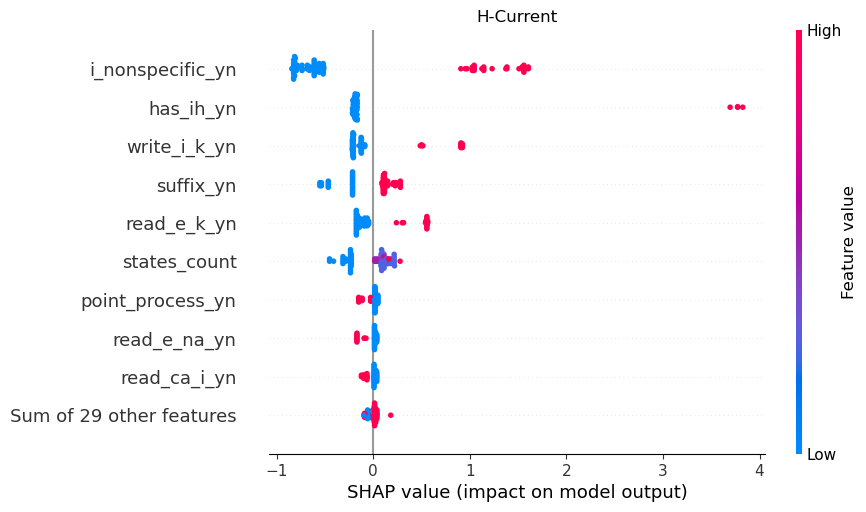

In [40]:
#H-Current
plt.title("H-Current")
shap.plots.beeswarm(shap_values[:,:,3])

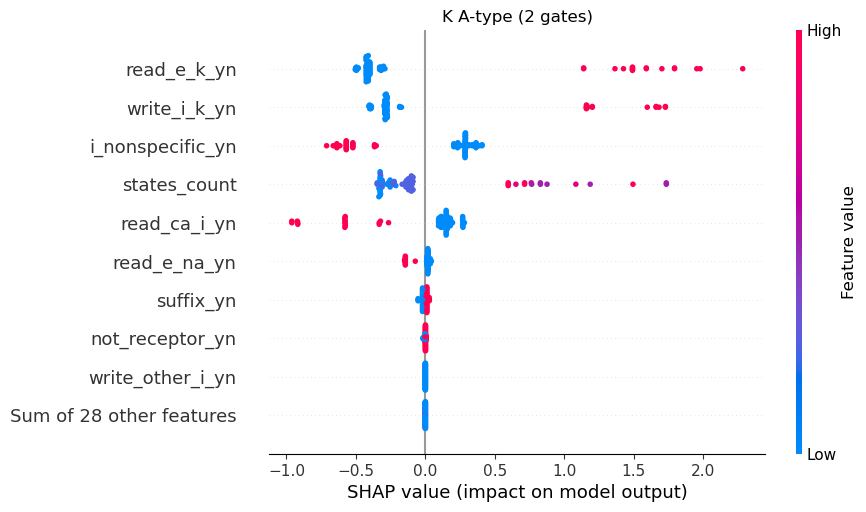

In [43]:
plt.title("K A-type (2 gates)")
shap.plots.beeswarm(shap_values[:,:,4])

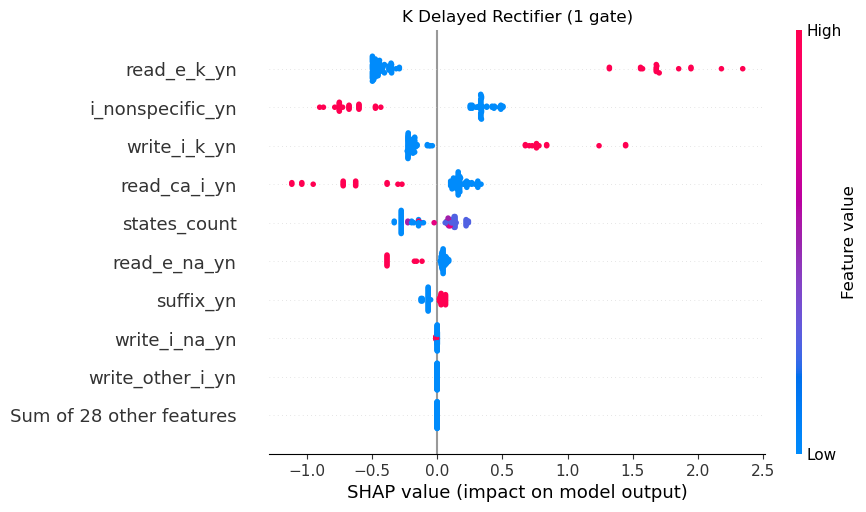

In [44]:
plt.title("K Delayed Rectifier (1 gate)")
shap.plots.beeswarm(shap_values[:,:,6])

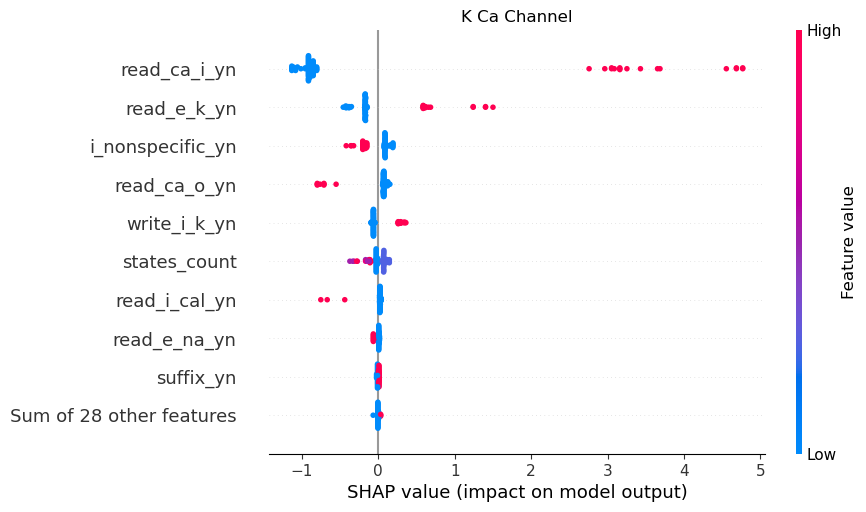

In [45]:
plt.title("K Ca Channel")
shap.plots.beeswarm(shap_values[:,:,5])

In [ ]:
#Transient Na+
plt.title("Na (transient) - 2 gates")
shap.plots.beeswarm(shap_values[:,:,13])

In [ ]:
shap.plots.beeswarm(shap_values[:,:,5])

# Compare to GPT

In [ ]:
import pandas as pd
import numpy as np

X_train = pd.read_csv("X_train.csv")
y_truth = pd.read_csv("y_truth.csv")
y_pred = pd.read_csv("y_pred.csv")
y_pred = np.array(y_pred).flatten()  # Ensures it's a 1D NumPy array
df_gpt = pd.read_csv("../data/mod_files_merged 3.csv")

In [ ]:
df_gpt_subset = df_gpt[df_gpt["hash"].isin(X_train["file_hash"])].copy()

In [ ]:
import pandas as pd
import ast

# List of column names to process
current_cols = ["currents_at_least_1", "currents_at_least_2", "currents_at_least_3"]

# Convert string lists into actual Python lists for all columns
for col in current_cols:
    df_gpt_subset[col] = df_gpt_subset[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Explode all columns, drop NaNs, and extract unique values
unique_currents = pd.concat([df_gpt_subset[col].explode() for col in current_cols]).dropna().unique()

# Convert to a sorted list (optional)
unique_currents_list = sorted(unique_currents)

# Print unique current names
print(unique_currents_list)


In [ ]:
columns_to_update = ["currents_at_least_1", "currents_at_least_2", "currents_at_least_3"]

# Apply the function to each element in the specified columns
for col in columns_to_update:
    df_gpt_subset[col] = df_gpt_subset[col].apply(lambda x: [map_new_label2(val) for val in x] if isinstance(x, list) else x)


In [ ]:
df_gpt_subset.reset_index(drop=True, inplace=True)

In [ ]:
View(df_gpt_subset.iloc[403])

In [ ]:
#View(df_gpt_subset[df_gpt_subset["currents_at_least_1"].apply(lambda x: "z_neither" in x)])

In [ ]:
df_gpt_predictions

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, jaccard_score

# Ensure dataset alignment
df_gpt_predictions = df_gpt_subset.set_index("hash")  # GPT model predictions
df_xgb_predictions = pd.DataFrame({"file_hash": X_train.index, "xgb_pred": y_pred}).set_index("file_hash")  # XGB predictions

In [ ]:

# Merge with GPT model predictions & ground truth labels
df_merged = df_xgb_predictions.join(df_gpt_predictions[["currents_at_least_1", "currents_at_least_2", "currents_at_least_3"]])
df_merged["ground_truth"] = y_truth  # Manually curated labels

In [ ]:
df_xgb_predictions

In [ ]:
import pandas as pd
import numpy as np
import ast  # Helps convert string representations of lists
from sklearn.metrics import classification_report

# Ensure dataset alignment
df_gpt_predictions = df_gpt_subset.set_index("hash")  # GPT model predictions
df_xgb_predictions = pd.DataFrame({"file_hash": X_train.index, "xgb_pred": y_train_pred}).set_index("file_hash")  # XGB predictions


In [ ]:
df_xgb_predictions

In [ ]:
df_gpt_predictions

In [ ]:
df_merged

In [ ]:
# Predict on test dataset
y_test_pred_encoded = xgb_model.predict(X_test)

# Convert predictions back to original label names
y_test_pred = label_encoder.inverse_transform(y_test_pred_encoded)

# Convert to a DataFrame (optional)
df_predictions = pd.DataFrame({"Predicted_Label": y_test_pred})
print(df_predictions.head())  # Show first few predictions

# Flagging Issues

In [ ]:
#row_id: 477 - commented out ranges included (https://modeldb.science/266818?tab=2&file=Ventricular_GUI.CircRes.ModelDB/Kss.mod)
#row_id: 481 - has comments with mod_state variables (https://modeldb.science/267511?tab=2&file=S1_Thal_NetPyNE_Frontiers_2022/sim/mod/ProbAMPANMDA_EMS.mod)
#row_id: 483 - has units in the mod_state ( https://modeldb.science/195666?tab=2&file=DewellGabbiani2018/mod_files/LGMD_KD_ca3.mod)
#row_id: 483 - was only extracting ONE parameter instead of multiple parameters (fixed)
#row_id 31 - has VALENCE in the write_ion (https://modeldb.science/116862?tab=2&file=b09jan13/IL3.mod)
#row_id 99 - need to fix use_ion

# Questions

In [ ]:
#todo: need to get INCLUDE for the notes table
#todo: should we collapse low-frequency labels
#todo: how do we process the SUFFIX, a lot of times the SUFFIX actually is the actual labeL?
#todo: do we include the name
#df["label"].value_counts()


In [ ]:
#REsol;ved Questions
#Is it okay that we make assumptions like start after READ and stop after WRITE, what if there is no WRITE statement?
#How to capture variables that are commented out vs. not? (don't capture stuff commented out)
#what's the best way to capture 


In [ ]:
View(df.loc[481,["url","mod_state"]],50)

In [ ]:
import re





In [99]:
! git add .
! git commit -m "added neither barplot"
! git push 

[main 4c0cbac] added neither barplot
 1 file changed, 70 insertions(+), 68 deletions(-)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 36 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 31.92 KiB | 2.28 MiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To github.com:innacohen/mod-extract.git
   c626ea8..4c0cbac  main -> main
